# Figure 17: does the network want a longer correlation length than $2\times2$?

This notebook reproduces `Plots/Fig_scale_search.pdf` (Fig. 17, App. F 2
"Searching for the relevant scale"). The notebook's file name predates the final figure
numbering.

### The question

The main text restricts the branch dictionary to patterns no larger than $2\times2$.
Before committing to that choice, this experiment checks whether TetrisCNN would prefer
a larger spatial scale if it were offered one. The default `smallkernels` dictionary
used everywhere else in the paper is swapped out for four deliberately coarse-grained
kernels spanning the full range of scales: $1\times1$, $2\times2$, $4\times4$, and the
full system size ($8\times8$ for Ising, $6\times7$ for XY), the `bigkernels` set. This
is otherwise the same $\lambda_{\max}$ sweep and classification (`partition`) task as
`FiguresApp_F_lambdamax.ipynb`, just run over a different kernel dictionary.

For both datasets, the network consistently suppresses every kernel larger than
$2\times2$ once the sparsity penalty crosses a modest threshold, at essentially no cost
to validation accuracy. The one exception is the XY $4\times4$ branch: suppressing it
costs about one percentage point of accuracy, suggesting it carries a small amount of
genuinely nonlocal information. Even so, the bulk of the predictive signal sits in the
local branches, which is what justifies restricting the main-text dictionary to
$2\times2$ and below.

### What it reads

Sweep folders under `Plots_data/sweeps/{Ising,XY_XZ}_plain_bigkernels_partition/`, the
same layout `FiguresApp_F_lambdamax.ipynb` reads (a sweep-level `metrics_per_lambda.json` plus one
representative seed's `config.json`). Both runs use the unconstrained ("plain")
architecture rather than the $C_4$-equivariant one, since the scale search is about
which spatial extent survives, not about rotational weight-tying.


In [1]:
import os

from tetriscnn import PAPER_MPLSTYLE
from tetriscnn.models import ShapeAdaptiveConvNet, SmallModel
from tetriscnn.utils import (
    AttrDict, load_json, DEVICE, kernel_to_latex_pattern
)
from tetriscnn.datasets import create_datasets

from pathlib import Path
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

plt.style.use(PAPER_MPLSTYLE)

# Paths below (Plots_data/ in, Plots/ out) are relative to the repository root;
# move there so the notebook runs the same from the root or from notebooks/.
os.chdir(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()))
Path("Plots/SVG").mkdir(parents=True, exist_ok=True)

## Loading a sweep

`_load_config_from_folder` and `_load_metrics_from_folder` are the same loaders used
throughout the paper-figure notebooks (see `FiguresApp_F_lambdamax.ipynb` for the full explanation of
the stride-compatibility fix they apply to older `config.json` kernel specs): they read
a run folder's `config.json` and `metrics.json` / `metrics_per_lambda.json` back into
the `AttrDict` the training code uses.


In [2]:
def _load_config_from_folder(seed_folder: Path) -> AttrDict:
    """Load config.json from a seed-level folder and return a populated AttrDict.

    Applies the stride-compatibility fix for kernels.
    Sets cf.logdir to the seed folder path.
    """
    cfg_path = seed_folder / "config.json"
    if not cfg_path.exists():
        raise FileNotFoundError(f"No config.json found in {seed_folder}")

    cf = AttrDict()
    cf.update(load_json(str(seed_folder), "config.json"))

    # Compatibility fix for kernels without stride specified (legacy runs)
    for k in range(len(cf.kernels)):
        if len(cf.kernels[k]) < 5:
            cf.kernels[k].append(1)

    cf.logdir = str(seed_folder)
    return cf

In [3]:
def _load_metrics_from_folder(seed_folder: Path, per_lambda=False):
    """Load metrics.json from a seed-level folder
    """
    if not per_lambda:
        cfg_path = seed_folder / "metrics.json"
        if not cfg_path.exists():
            raise FileNotFoundError(f"No metrics.json found in {seed_folder}")

        metrics = load_json(str(seed_folder), "metrics.json")
    else:
        cfg_path = seed_folder / "metrics_per_lambda.json"
        if not cfg_path.exists():
            raise FileNotFoundError(f"No metrics_per_lambda.json found in {seed_folder}")

        metrics = load_json(str(seed_folder), "metrics_per_lambda.json")
    return metrics

## Aggregating and drawing a sweep

`_mean_ste`, `_aggregate`, `_stack` and `_draw_panels` are the same reduction and
plotting machinery as `FiguresApp_F_lambdamax.ipynb` (see there for the normalization convention:
branch activations are normalized by their own per-seed maximum before averaging, since
the absolute scale of $z_k$ carries no physical meaning on its own, only the relative
size across branches does). `_aggregate` reads out whichever metrics a run recorded, so
the same function serves both the classification sweep here and a regression sweep
elsewhere.

The cell below applies this to the Ising sweep alone and draws a standalone figure
(`fig_ising`). This is an exploratory view, never written to `Plots/`: it exists to
inspect the sweep with every optional panel available (most are commented out in
`metrics_to_plot`) before committing to the two panels, branch activations (`z`) and
validation accuracy (`val_acc`), that the published figure actually keeps.


In [4]:
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ── shared helpers (defined once, used by both models) ────────────────────────
def _mean_ste(arr):
    arr = np.array(arr)
    return arr.mean(axis=0), arr.std(axis=0, ddof=1) / np.sqrt(len(arr))

def _aggregate(metrics_dict, cf):
    """Aggregate per-lambda metrics into a results dict keyed by float lambda."""
    lambdas_str = list(metrics_dict.keys())
    lambdas     = np.array([float(k) for k in lambdas_str])
    results = {}
    try:
        metrics_dict[lambdas_str[0]]["z"]
    except KeyError:
        from collections import defaultdict

        result = defaultdict(lambda: defaultdict(list))

        for lam, seeds in metrics_dict.items():
            for seed, metrics in seeds.items():
                for metric, value in metrics.items():
                    result[lam][metric].append(value)

        metrics_dict = {lam: dict(metrics) for lam, metrics in result.items()}

    for lam, lam_str in zip(lambdas, lambdas_str):
        r = {}
        z = np.abs(np.array(metrics_dict[lam_str]["z"]).squeeze())
        z = z / z.max(axis=1, keepdims=True)
        r["z"], r["z_ste"] = _mean_ste(z)

        if "val_r2agg" in metrics_dict[lam_str]:
            r2 = np.array(metrics_dict[lam_str]["val_r2agg"])
            r["r2agg"], r["r2agg_ste"] = _mean_ste(r2)

        if "val_MSE" in metrics_dict[lam_str]:
            mse = np.array(metrics_dict[lam_str]["val_MSE"])
            r["val_MSE"], r["val_MSE_ste"] = _mean_ste(mse)

        if "val_CEL" in metrics_dict[lam_str]:
            cel = np.array(metrics_dict[lam_str]["val_CEL"])
            r["val_CEL"], r["val_CEL_ste"] = _mean_ste(cel)

        if "val_acc" in metrics_dict[lam_str]:
            acc = np.array(metrics_dict[lam_str]["val_acc"])
            r["val_acc"], r["val_acc_ste"] = _mean_ste(acc)

        if "pt" in metrics_dict[lam_str]:
            deriv = np.array([x for x, _ in metrics_dict[lam_str]["pt"]])
            peak  = np.array([y for _, y in metrics_dict[lam_str]["pt"]])
            r["pt_deriv"], r["pt_deriv_ste"] = _mean_ste(deriv)
            r["pt"],       r["pt_ste"]       = _mean_ste(peak)

        results[lam] = r
    return lambdas, results

def _stack(results, lambdas, metric):
    try:
        return np.array([results[lam][metric] for lam in lambdas])
    except KeyError:
        return None

def _draw_panels(axs, results, lambdas, cf, active, pt_label, deriv_label,
                 show_legend=True, titles=None, title_loc="left", supress_titles=False, colors = None):
    """Draw active metric panels into the provided axes column.

    Parameters
    ----------
    show_legend : bool
        Whether to draw the per-kernel legend on the z panel.
    titles : list[str] | None
        Override panel titles (one per active panel). None keeps defaults.
    title_loc : str
        Matplotlib title loc: "left", "center", or "right".
        Pass "inside" to place the title as an in-axes text at the top-left.
    """
    norm_pt = None
    legend_handles = []

    for i, m in enumerate(active):
        ax   = axs[i]
        mean = _stack(results, lambdas, m["name"])
        ste  = _stack(results, lambdas, m["name"] + "_ste")

        if mean is None:
            ax.axis("off")
            continue

        mean = mean.squeeze()
        if ste is not None:
            ste = ste.squeeze()

        if m.get("per_kernel"):
            for k in range(mean.shape[1]):
                label = kernel_to_latex_pattern(cf.kernels[k], full_latex=True)
                if colors is not None:
                    color = colors[k % len(colors)]
                    ln, = ax.plot(lambdas, 
                                mean[:, k], 
                                "o-", 
                                label=label,
                                color=color,
                                #markersize=3
                                )
                else:
                    ln, = ax.plot(lambdas, 
                                mean[:, k], 
                                ".-", 
                                label=label)
                    
                legend_handles.append(ln)

                if ste is not None and colors is not None:
                    ax.fill_between(lambdas, 
                                    mean[:, k] - ste[:, k],
                                    mean[:, k] + ste[:, k], 
                                    color=color,
                                    alpha=0.3)
                elif ste is not None:
                    ax.fill_between(lambdas, mean[:, k] - ste[:, k],
                                    mean[:, k] + ste[:, k], alpha=0.3)
            if show_legend:
                legend = ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", ncol=2, fontsize=8)
                for txt, ln in zip(legend.get_texts(), legend.get_lines()):
                    txt.set_color(ln.get_color())

        elif m.get("heatmap"):
            if norm_pt is None:
                norm_pt = Normalize(vmin=mean.min(), vmax=mean.max())
            im = ax.imshow(mean.T, aspect="auto", cmap="viridis",
                           interpolation="nearest",
                           extent=[lambdas[0], lambdas[-1], 0, 1],
                           origin="lower", norm=norm_pt)
            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size="3%", pad=0.05)
            ax.get_figure().colorbar(im, cax=cax).set_label(deriv_label)
            ax.set_yticks([])
            ax.grid(False)

        else:
            color = m.get("color", "0.3")
            ax.plot(lambdas, mean, "o-", color=color)
            if ste is not None:
                ax.fill_between(lambdas, mean - ste, mean + ste, alpha=0.3, color=color)
            ax.grid(True)

        if not supress_titles:
            panel_title = titles[i] if titles is not None else m["title"]
            if title_loc == "inside":
                ax.text(0.02, 0.97, panel_title, transform=ax.transAxes,
                        fontsize=9, va="top", ha="left")
            else:
                ax.set_title(panel_title, loc=title_loc)
        ax.set_ylabel(m["ylabel"], labelpad=10)

    # axs[-1].set_xlabel(r"$\lambda_{\max}$")
    # axs[-1].set_xticks(lambdas)
    # axs[-1].set_xticklabels([rf"$10^{{{lam:g}}}$" for lam in lambdas])

    axs[-1].set_xlabel(r"$\log_{10}\lambda_{\max}$")
    axs[-1].set_xticks(lambdas)
    axs[-1].set_xticklabels([rf"${lam:g}$" for lam in lambdas])
    

    return legend_handles  # caller can place a figure-level legend


In [5]:
# Plain big-kernel lambda-max sweep (Ising, `partition` task). The folder holds
# the sweep-level metrics_per_lambda.json plus one representative seed config.json;
# copied out of the gitignored logs/ tree -- see Plots_data/README.md.
ising_basepath = Path("Plots_data/sweeps/Ising_plain_bigkernels_partition")

/var/folders/ny/xk8kjhk1187_wmh8cphjtsz80000gn/T/ipykernel_84213/1013156117.py:35: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


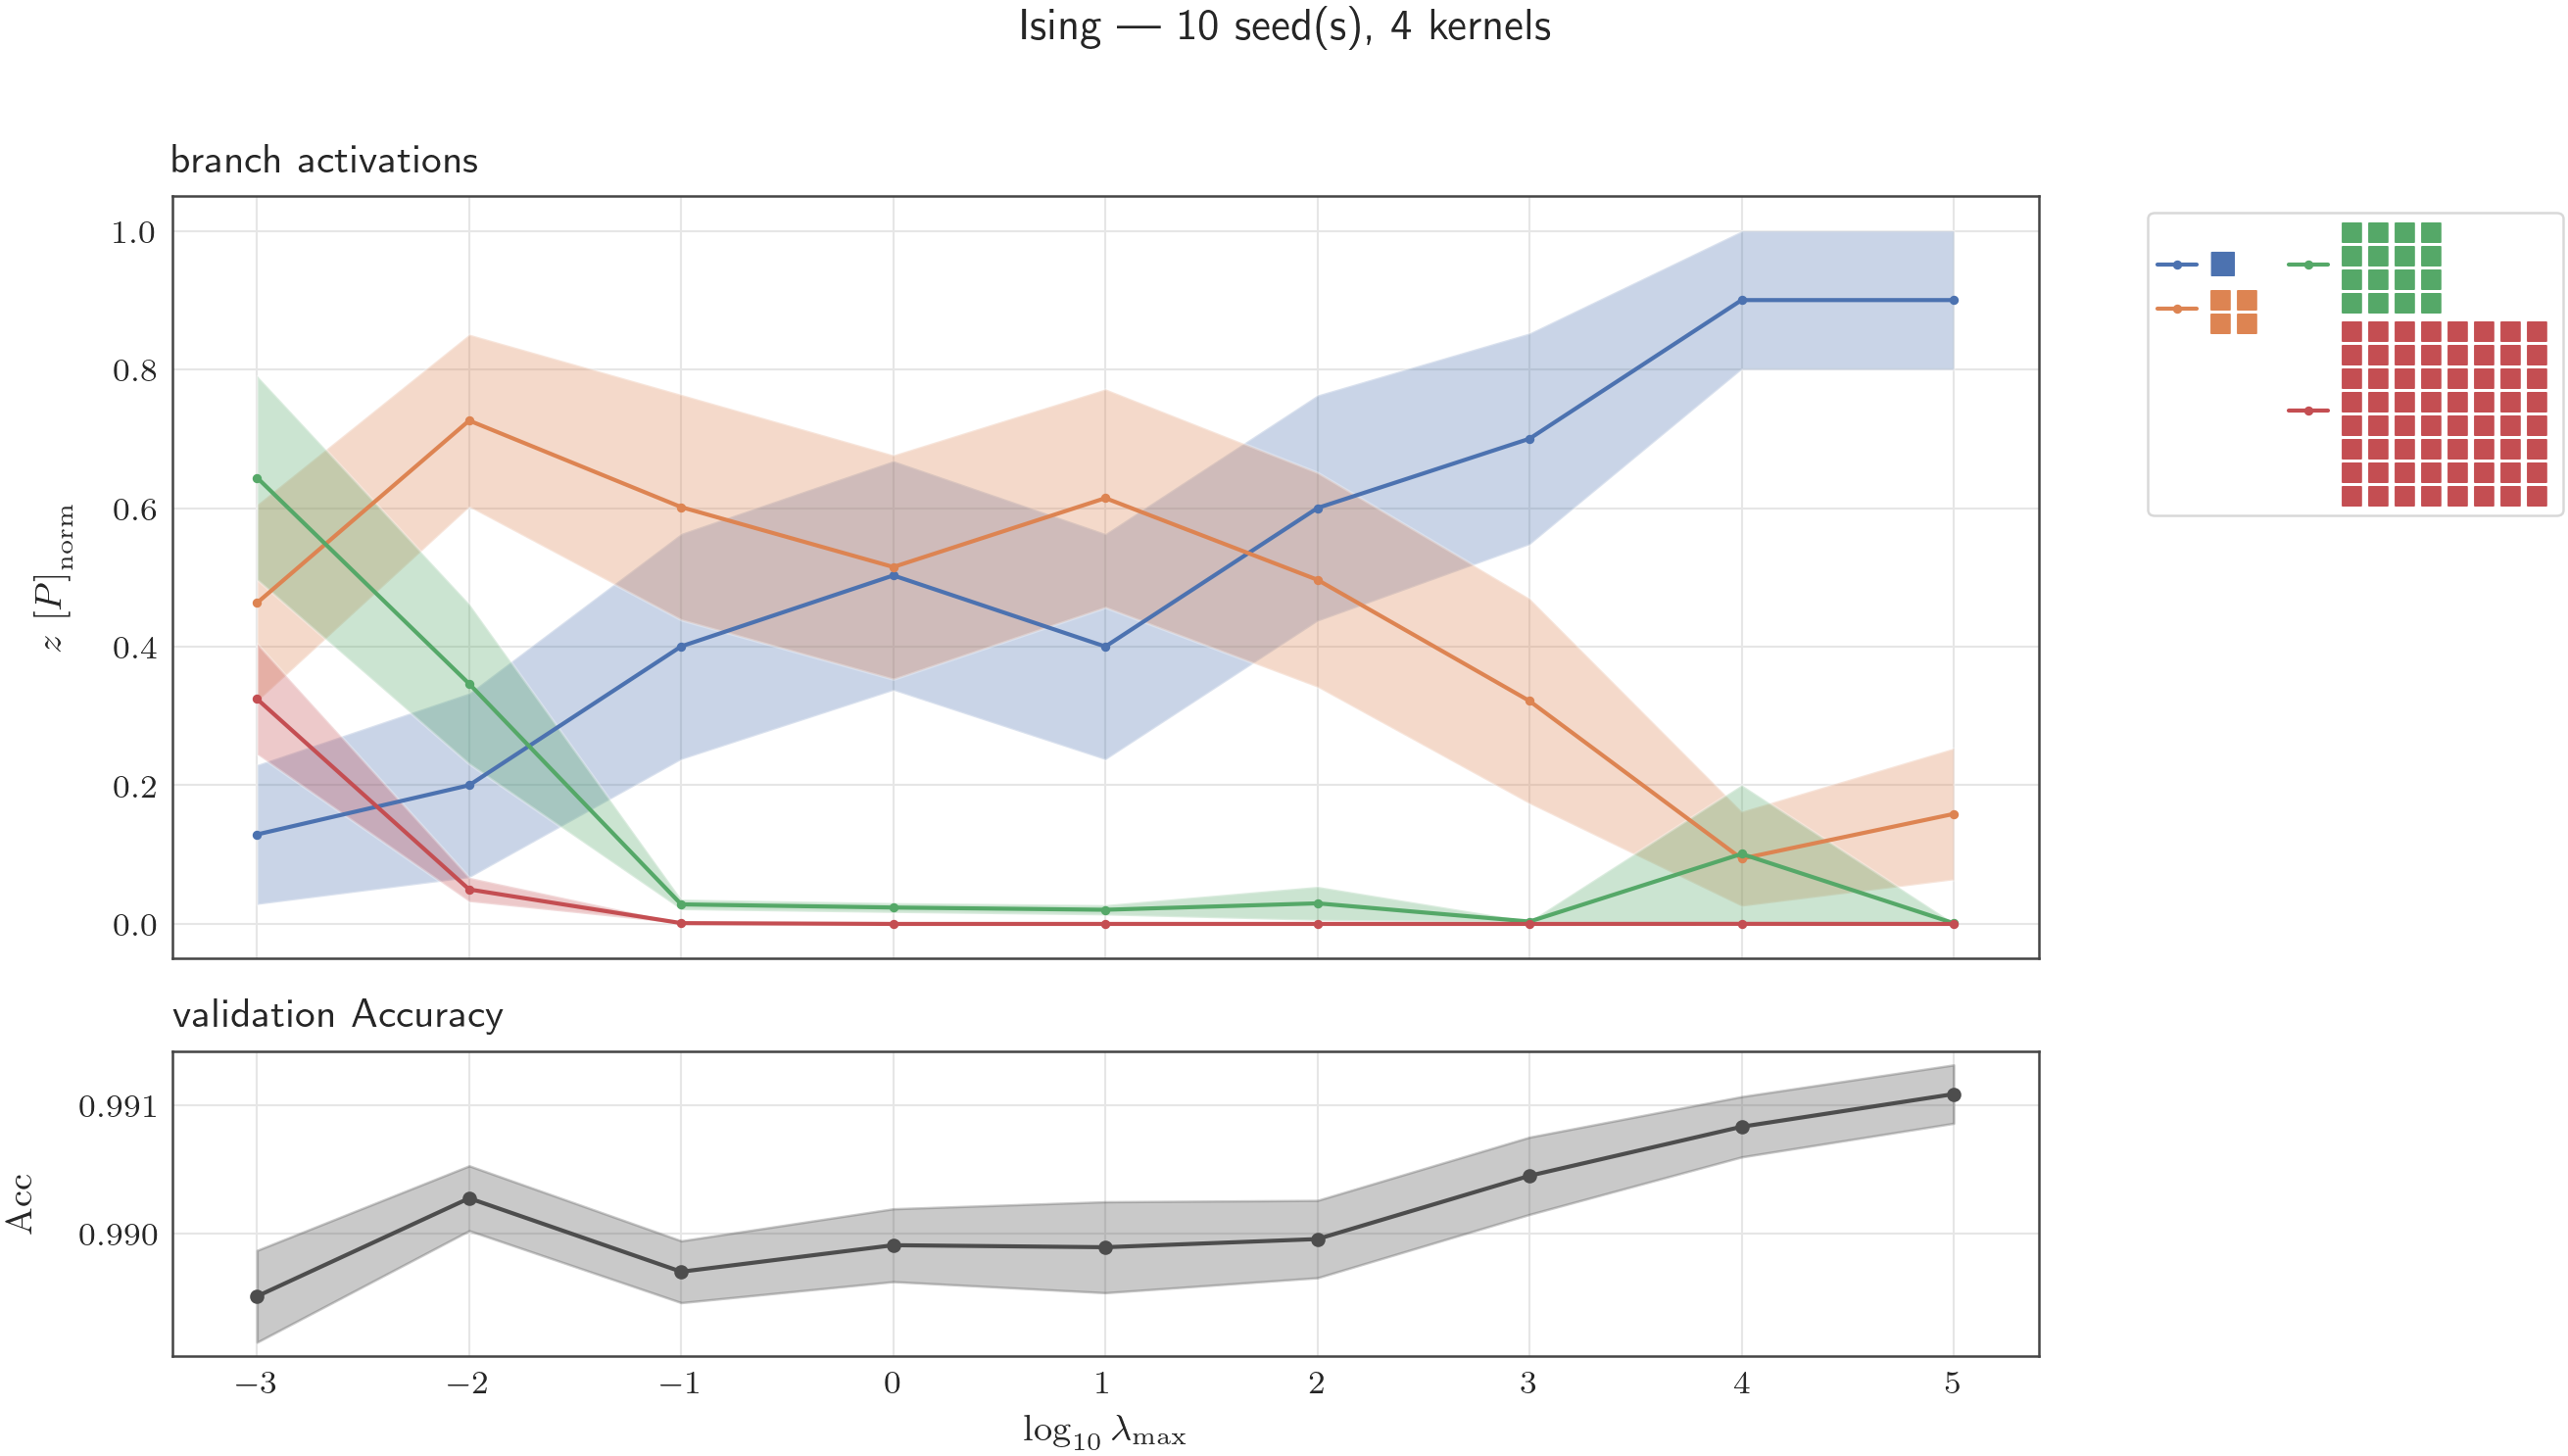

In [6]:
# ── Ising model ───────────────────────────────────────────────────────────────
ising_metrics  = _load_metrics_from_folder(ising_basepath, per_lambda=True)
cf_ising       = _load_config_from_folder(ising_basepath)

ising_lambdas, ising_results = _aggregate(ising_metrics, cf_ising)

# ── panel config (shared for both models) ────────────────────────────────────
enabled_metrics = {"z", "val_acc"}   # set to None to show all panels
pt_label    = r"$\delta$"
deriv_label = r"$d\hat\delta/d\delta$"

metrics_to_plot = [
    # dict(name="z",        ylabel="z (norm)", title="branch activations",           per_kernel=True),
    dict(name="z",        ylabel=r"$z\,\left[P\right]_{\rm norm}$", title="branch activations", per_kernel=True),
    # dict(name="r2agg",    ylabel=r"$R^2_\mathrm{agg}$",   title=r"validation $R^2_{\rm agg}$"),
    dict(name="val_acc",    ylabel=r"$\mathrm{Acc}$",   title=r"validation Accuracy"),
    # dict(name="val_MSE",  ylabel=r"MSE",             title="validation MSE",     color="steelblue"),
    # dict(name="val_CEL",  ylabel=r"CEL",             title="validation CEL",     color="steelblue"),
    # dict(name="pt",       ylabel=pt_label,   title=f"phase indicator {pt_label}",  color="magenta"),
    # dict(name="pt_deriv", ylabel=deriv_label,title=deriv_label,                    heatmap=True),
]
active = [m for m in metrics_to_plot if enabled_metrics is None or m["name"] in enabled_metrics]

# ── Ising standalone plot ─────────────────────────────────────────────────────
height_ratios = [5] + [2] * (len(active) - 1)
fig_ising, axs_ising = plt.subplots(len(active), 1,
                                     figsize=(9, 3 + (len(active) - 1) * 2),
                                     sharex=True,
                                     gridspec_kw={"height_ratios": height_ratios})
if len(active) == 1:
    axs_ising = [axs_ising]

_draw_panels(axs_ising, ising_results, ising_lambdas, cf_ising, active, pt_label, deriv_label)
fig_ising.suptitle(f"Ising — {len(cf_ising.seeds)} seed(s), {len(cf_ising.kernels)} kernels", y=1.01)
plt.tight_layout()
plt.show()

## The same procedure for the XY sweep

Identical to the Ising cell above, pointed instead at
`Plots_data/sweeps/XY_XZ_plain_bigkernels_partition`. `fig_xy` is again an exploratory
plot, not written to disk; the published figure is assembled fresh from `ising_results`
and `xy_results` in the next section.


In [7]:
# Plain big-kernel lambda-max sweep (XY XZ, `partition` task).
xy_basepath = Path("Plots_data/sweeps/XY_XZ_plain_bigkernels_partition")

In [8]:
xy_metrics  = _load_metrics_from_folder(xy_basepath, per_lambda=True)
cf_xy       = _load_config_from_folder(xy_basepath)

/var/folders/ny/xk8kjhk1187_wmh8cphjtsz80000gn/T/ipykernel_84213/561756584.py:14: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


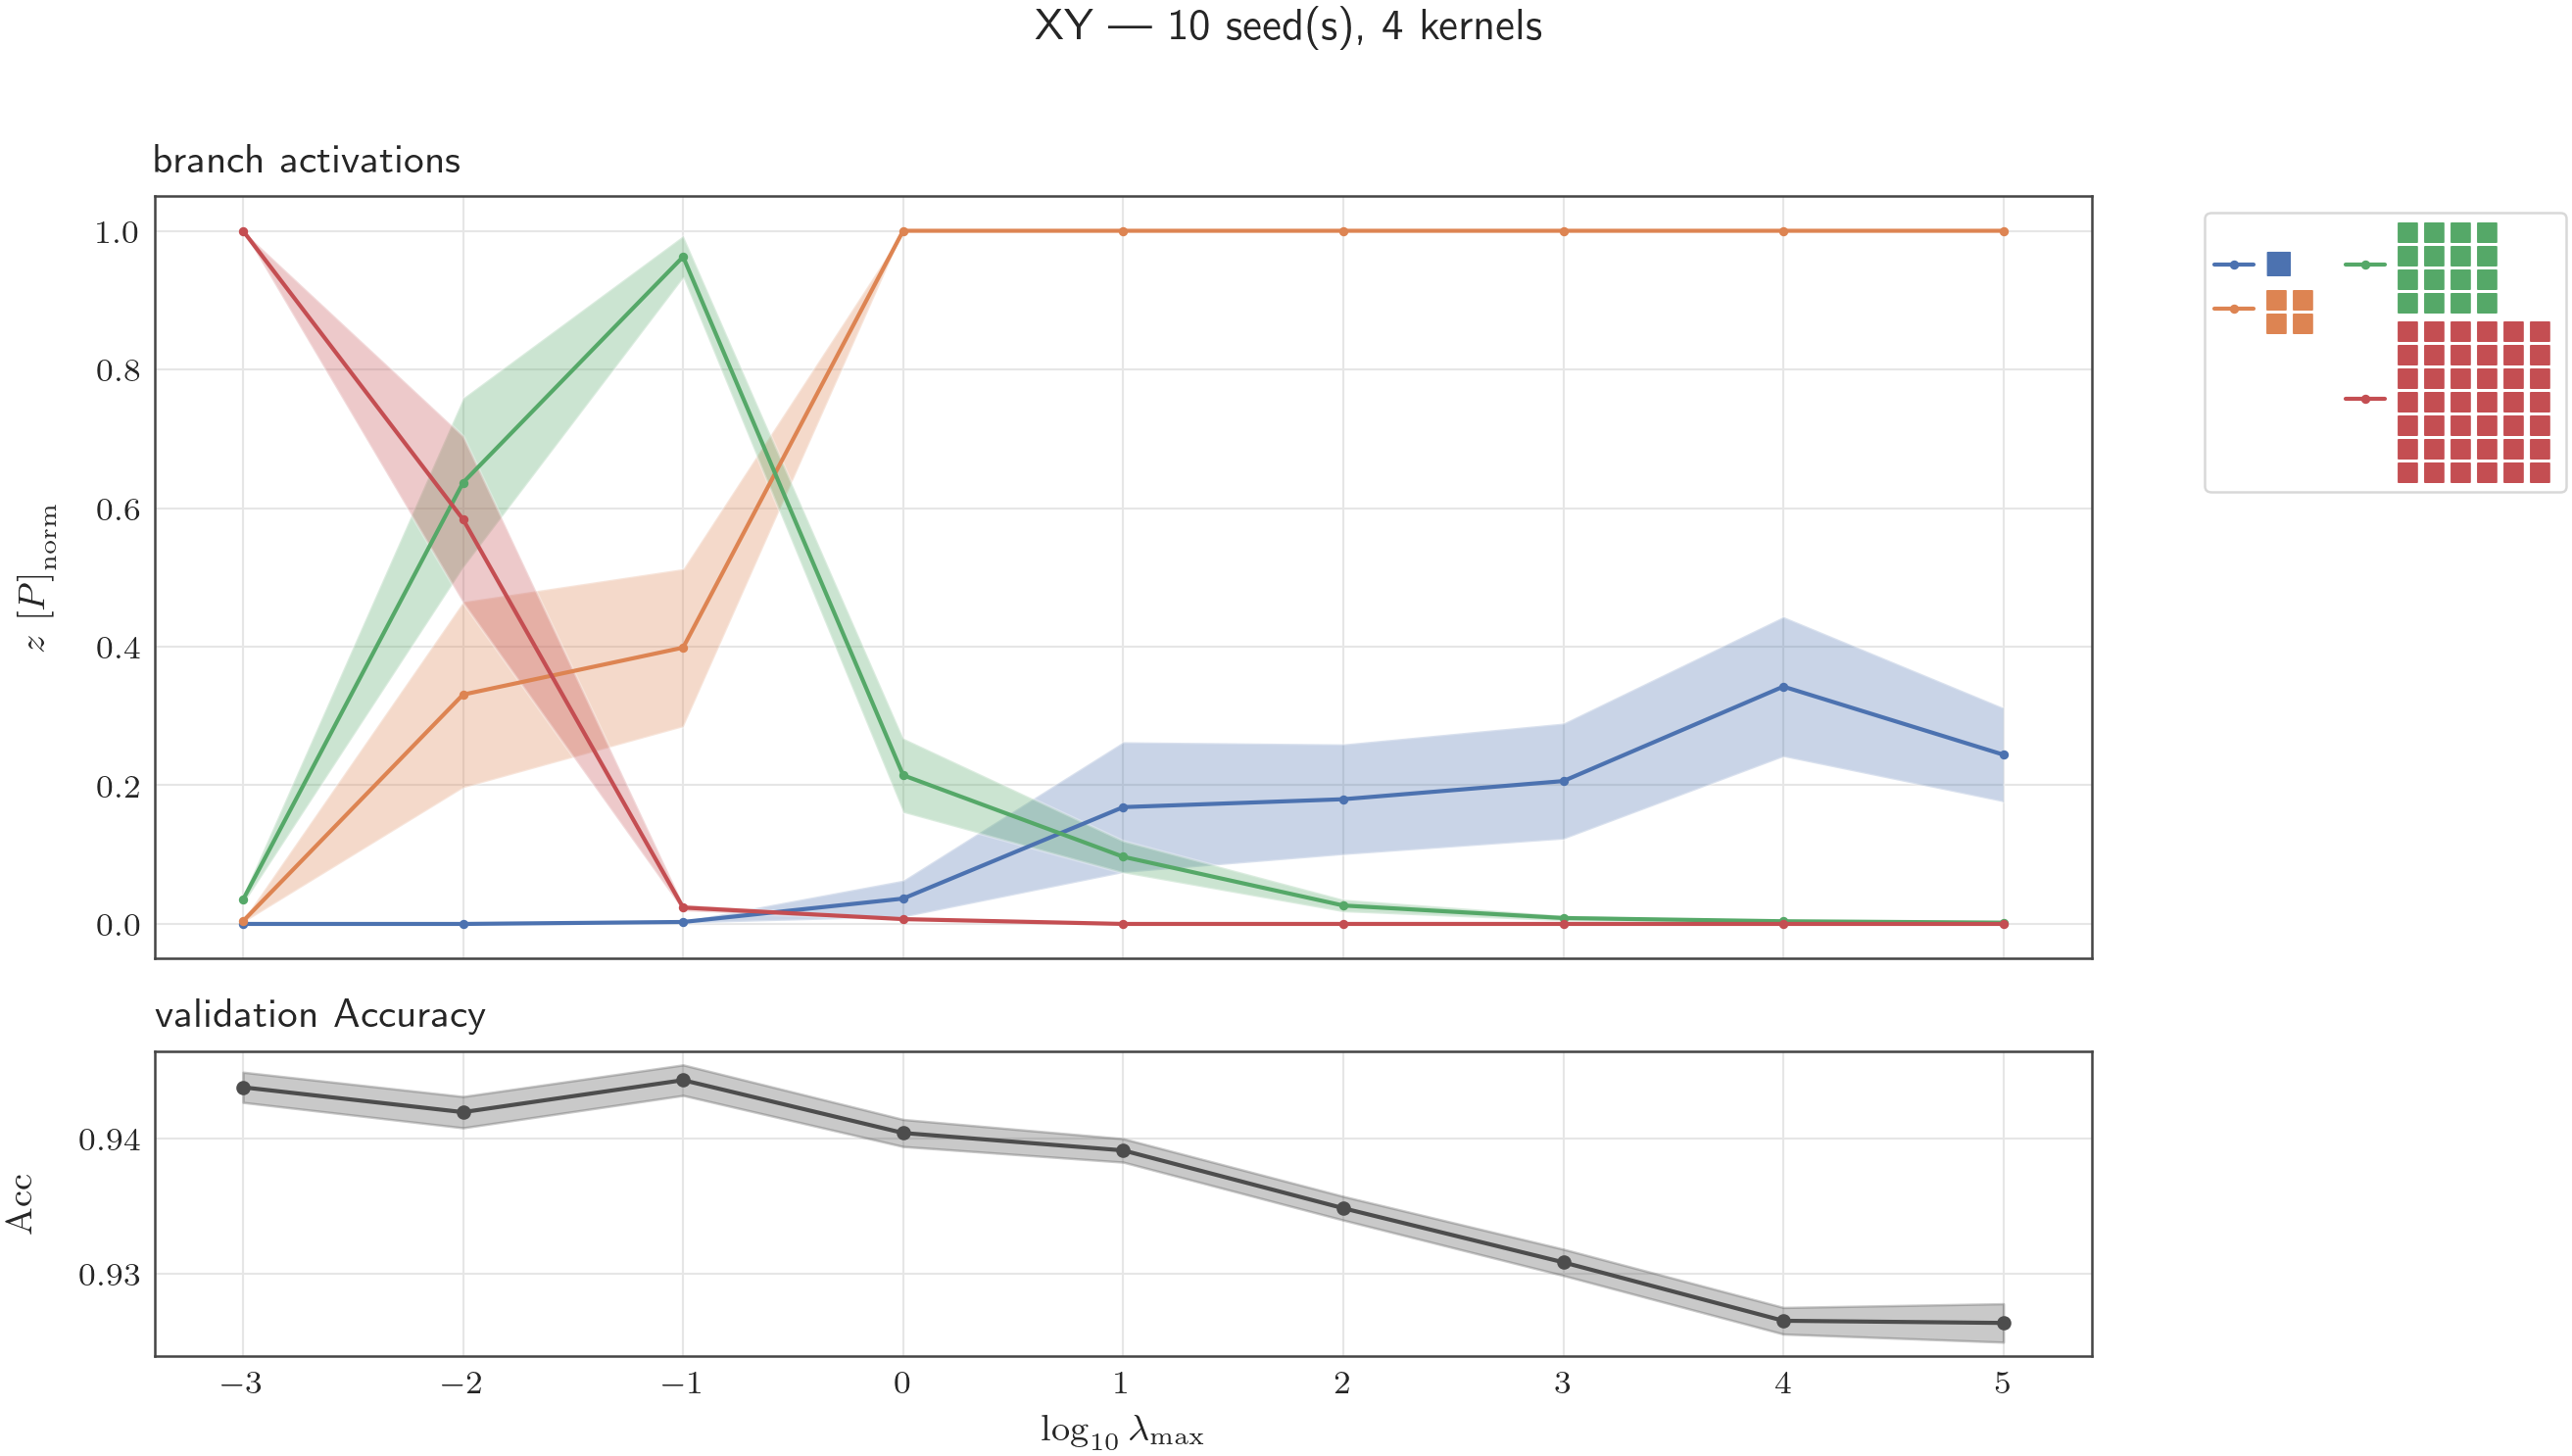

In [9]:
xy_lambdas, xy_results = _aggregate(xy_metrics, cf_xy)

# ── XY standalone plot ────────────────────────────────────────────────────────
height_ratios = [5] + [2] * (len(active) - 1)
fig_xy, axs_xy = plt.subplots(len(active), 1,
                               figsize=(9, 3 + (len(active) - 1) * 2),
                               sharex=True,
                               gridspec_kw={"height_ratios": height_ratios})
if len(active) == 1:
    axs_xy = [axs_xy]

_draw_panels(axs_xy, xy_results, xy_lambdas, cf_xy, active, pt_label, deriv_label)
fig_xy.suptitle(f"XY — {len(cf_xy.seeds)} seed(s), {len(cf_xy.kernels)} kernels", y=1.01)
plt.tight_layout()
plt.show()


## The published figure: Ising and XY side by side

The cell below's own header comment, "three models side-by-side (XY Z | XY XZ |
Ising)", describes an earlier, abandoned layout: an additional $Z$-basis-only XY sweep
was going to sit alongside the combined-basis one, and its loader is still present but
commented out and never executed. As the cell actually runs, `for col in range(2)`
builds exactly two columns from the `ising_results` and `xy_results` computed above, the
`bigkernels` sweep for each dataset, and that two-column, two-row layout is what
`fig:big_kernels` shows. Panel letters read (a) Ising activations, (b) XY activations,
(c) Ising accuracy, (d) XY accuracy, matching the caption's "(a,c) Ising, (b,d) XY"
grouping. The final cell saves this figure to `Plots/Fig_scale_search.pdf`, plus a
parallel `Plots/SVG/` copy kept as a convenience and not referenced by the
manuscript.


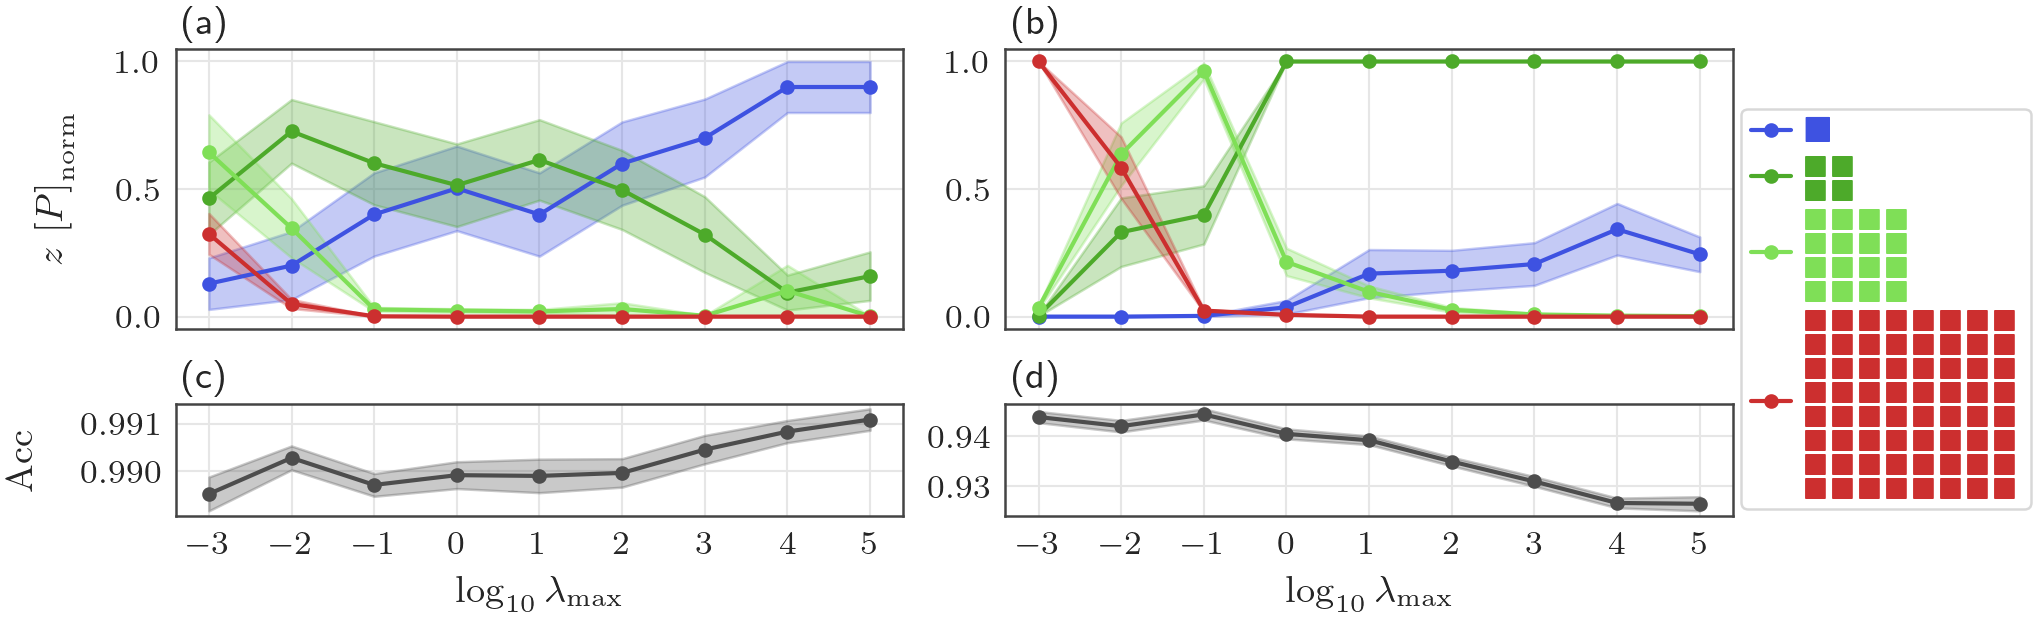

In [10]:
# Final plot - three models side-by-side (XY Z | XY XZ | Ising), one row per panel
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches

important_alpha = 1.0
unimportant_alpha = 0.35

from tetriscnn.colors import colors

# ── Load XY Z-basis ───────────────────────────────────────────────────────────
# xy_z_basepath = Path("logs/lambdamax_experiment_bigkernels/SL/XY_Z")
# xy_z_metrics  = _load_metrics_from_folder(xy_z_basepath, per_lambda=True)
# cf_xy_z       = _load_config_from_folder(xy_z_basepath)
# xy_z_lambdas, xy_z_results = _aggregate(xy_z_metrics, cf_xy_z)

# ── Panel config: replace pt with val_MSE ────────────────────────────────────
# enabled_metrics = {"z", "r2agg", "val_MSE"}
enabled_metrics = {"z", "val_acc"}

metrics_to_plot = [
    # dict(name="z",       ylabel="z (norm)",                        title="branch activations", per_kernel=True),
    dict(name="z",        ylabel=r"$z\,\left[P\right]_{\rm norm}$", title="branch activations",           per_kernel=True),
    # dict(name="r2agg",   ylabel=r"$R^2_\mathrm{agg}$",            title=r"validation $R^2_{\rm agg}$"),
    dict(name="val_acc",   ylabel=r"$\mathrm{Acc}$",            title=r"validation Accuracy"),
    # dict(name="val_CEL", ylabel=r"CEL",                       title="validation CEL",     color="steelblue"),
    # dict(name="val_MSE", ylabel=r"MSE",                       title="validation MSE",     color="steelblue"),
]
active = [m for m in metrics_to_plot if enabled_metrics is None or m["name"] in enabled_metrics]

n_panels = len(active)
#height_ratios = [5] + [2] * (n_panels - 1)

plt.style.use(PAPER_MPLSTYLE)

DOUBLE_WIDTH = 6.80914
golden_ratio = (1 + np.sqrt(5)) / 2
# fig_final = plt.figure(figsize=(DOUBLE_WIDTH, 0.65*DOUBLE_WIDTH/golden_ratio))
fig_final = plt.figure(figsize=(DOUBLE_WIDTH, 0.5*DOUBLE_WIDTH/golden_ratio))
gs = gridspec.GridSpec(n_panels, 3, figure=fig_final,
                    height_ratios=[1,0.4],
                    # width_ratios=[1,1,0.35],   
                    width_ratios=[1,1,0.4],   
                    #hspace=0.05, wspace=0.03
                    )

# Column order: XY Z | XY XZ | Ising
axs_col = []
for col in range(2):
    col_axs = [fig_final.add_subplot(gs[0, col])]
    for r in range(1, n_panels):
        col_axs.append(fig_final.add_subplot(gs[r, col], sharex=col_axs[0]))
    axs_col.append(col_axs)

axs_ising, axs_xy_xz = axs_col

# legend_handles = _draw_panels(axs_xy_z,  xy_z_results,  xy_z_lambdas,  cf_xy_z,
#                             active, pt_label, deriv_label, show_legend=False, supress_titles=True)
legend_handles = _draw_panels(axs_xy_xz, xy_results, xy_lambdas, cf_xy,
            active, pt_label, deriv_label, show_legend=False, supress_titles=True, colors=colors)
_draw_panels(axs_ising,  ising_results, ising_lambdas, cf_ising,
            active, pt_label, deriv_label, show_legend=False, supress_titles=True, colors=colors)

# Remove y-labels from middle and right columns
for ax in axs_xy_xz:
    ax.set_ylabel("")

# Hide x-tick labels on all but the bottom row
for col_axs in axs_col:
    for ax in col_axs[:-1]:
        plt.setp(ax.get_xticklabels(), visible=False)
        ax.set_xlabel("")


# Figure-level legend centred above the three columns
legend_labels = [kernel_to_latex_pattern(cf_ising.kernels[k], full_latex=True)
                for k in range(len(cf_ising.kernels))]
fig_legend = fig_final.legend(
    handles=legend_handles,
    labels=legend_labels,
    loc="center left",
    # bbox_to_anchor=(0.54, 1.12),
    bbox_to_anchor=(0.8475, 0.5),
    # ncol=len(legend_handles),
    ncol=1,
    #fontsize=15,
    #frameon=True,
)
for txt, ln in zip(fig_legend.get_texts(), fig_legend.get_lines()):
    txt.set_color(ln.get_color())

# Subplot labels (a)–(i), 3 columns × 3 rows
letters = "abcd"
# ypos_per_row = [1.02, 1.03]
ypos_per_row = [1.02, 1.06]
# xpos = 0.94
xpos = 0.01

for row_idx, row_ypos in enumerate(ypos_per_row):
    for col_idx, col_axs in enumerate(axs_col):
        letter = letters[row_idx * 2 + col_idx]
        col_axs[row_idx].text(xpos, row_ypos, f"({letter})",
                            transform=col_axs[row_idx].transAxes,
                            va="bottom")

#plt.show()
# fig_final.savefig("Plots/Fig8.pdf")
                #   bbox_inches="tight", 
                #   bbox_extra_artists=[fig_legend])


In [11]:
fig_final.savefig("Plots/Fig_scale_search.pdf")
fig_final.savefig("Plots/SVG/Fig_scale_search.svg")
print("wrote Plots/Fig_scale_search.pdf")

wrote Plots/Fig_scale_search.pdf
